In [1]:
import qutip as qt
import matplotlib.pyplot as plt
import numpy as np

n_cutoff_A = 2
n_cutoff_B = 2
n_cutoff_rA = 2
n_cutoff_rB = 2

# destroy: annihilation operator
# qeye: identity operator
b_A = qt.tensor(qt.destroy(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
b_B = qt.tensor(qt.qeye(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.destroy(n_cutoff_B))
a_A = qt.tensor(qt.qeye(n_cutoff_A), qt.destroy(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
a_B = qt.tensor(qt.qeye(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.destroy(n_cutoff_rB), qt.qeye(n_cutoff_B))

f0_A = qt.tensor(qt.basis(n_cutoff_A, 1), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
g1_A = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 1), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
f0_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 1))
g1_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 1), qt.basis(n_cutoff_B, 0))


In [2]:
from mpmath import *
def gamma_t(time, time0, center, const, form="sech", reverse=False):
        if reverse:
            time = -time
            # time0 = -time0
        def Li_2(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(2, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_3(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(3, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_4(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(4, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_5(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(5, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_6(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(6, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        if form=="sech_0":
            top = (const/2)/(np.cosh(const*(time-center)))**2
            bottom = 1-(1/2)*(np.tanh(const*(time-center))-np.tanh(const*(time0-center)))
        elif form=="sech_1":                                                      
            top = (6*const**3/np.pi**2)*(time-center)**2/(np.cosh(const*(time-center)))**2
            def f(t):
                return 6 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) / np.pi**2
            bottom = 1-(f(const*(time-center))-f(const*(time0-center)))
        elif form=="sech_2":                                                    
            top = (45*const**5/2/np.pi**4) * ((time-center)**2 - (np.pi/const)**2/12)**2/ (np.cosh(const * (time - center)))**2
            def f(t):
                f_2 = 6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1)
                f_1 = -np.pi**2 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) /6
                f_0 = np.pi**4*np.tanh(t)/144
                return 45*(f_2 + f_1 + f_0)/2/np.pi**4
            bottom = 1 - (f(const * (time - center)) - f(const * (time0 - center)))
        elif form=="sech_3":
            top = (350*const**7/9/np.pi**6) * ((time-center)**3 - 7*(np.pi/const)**2/20*(time-center))**2/ (np.cosh(const * (time - center)))**2
            def f(t):
                f_3 = 15*t**4*Li_2(t) + 30*t**3*Li_3(t) + 45*t**2*Li_4(t) + 45*t*Li_5(t) + 45/2*Li_6(t) - t**6*(1 - np.tanh(t)) - 6*t**5*np.log(np.exp(-2 * t) + 1)
                f_2 = -7*np.pi**2*(6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1))/10
                f_1 =  (7*np.pi**2/20)**2* (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t)))
                return 350*(f_3 + f_2 + f_1)/9/np.pi**6
            bottom = 1 - (f(const * (time - center)) - f(const * (time0 - center)))
        return top/bottom/2/np.pi

In [3]:
def H_fogi_A(t, args):
    g_g1f0 = gamma_t(t, args["time0"], args["center_A"], args["const"], args["mode_A"])*a_A*b_A.dag()#*b_A.dag()
    g_f0g1 = np.conj(gamma_t(t, args["time0"], args["center_A"], args["const"], args["mode_A"]))*a_A.dag()*b_A#*b_A
    g_f0f0 = 1j*args["kappa_A"]*b_A.dag()*b_A/2 #.dag()*b_A*b_A/2
    return  g_g1f0 + g_f0g1 + g_f0f0

def H_fogi_B(t, args):
    g_g1f0 = gamma_t(t, args["time0"], args["center_B"], args["const"], args["mode_B"], True)*a_B*b_B.dag()#*b_B.dag()
    g_f0g1 = np.conj(gamma_t(t, args["time0"], args["center_B"], args["const"], args["mode_B"], True))*a_A.dag()*b_B#*b_B
    g_f0f0 = 1j*args["kappa_B"]*b_B.dag()*b_B/2 #.dag()*b_B*b_B/2
    return g_g1f0 + g_f0g1 + g_f0f0

def H_c(t, args):
    return 1j*(args["eta"]*args["kappa_A"]*args["kappa_B"])**0.5*(a_A.dag()*a_B - a_A*a_B.dag())

10.0%. Run time:   0.22s. Est. time left: 00:00:00:01
20.0%. Run time:   0.43s. Est. time left: 00:00:00:01
30.0%. Run time:   0.63s. Est. time left: 00:00:00:01
40.0%. Run time:   0.85s. Est. time left: 00:00:00:01
50.0%. Run time:   1.06s. Est. time left: 00:00:00:01
60.0%. Run time:   1.28s. Est. time left: 00:00:00:00
70.0%. Run time:   1.59s. Est. time left: 00:00:00:00
80.0%. Run time:  13.10s. Est. time left: 00:00:00:03
90.0%. Run time:  14.72s. Est. time left: 00:00:00:01
100.0%. Run time:  14.92s. Est. time left: 00:00:00:00
Total run time:  14.92s


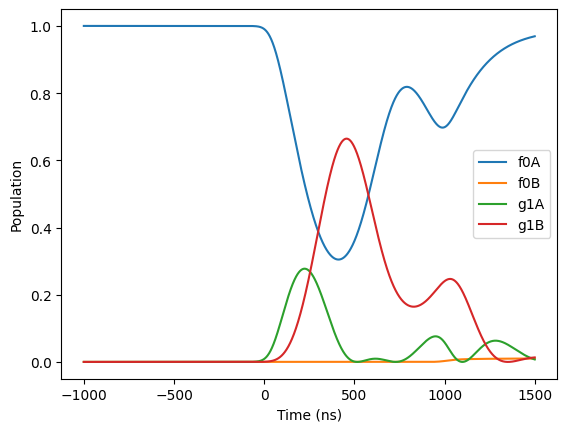

10.0%. Run time:   0.21s. Est. time left: 00:00:00:01
20.0%. Run time:   0.43s. Est. time left: 00:00:00:01
30.0%. Run time:   0.64s. Est. time left: 00:00:00:01
40.0%. Run time:   0.86s. Est. time left: 00:00:00:01
50.0%. Run time:   1.07s. Est. time left: 00:00:00:01
60.0%. Run time:   1.28s. Est. time left: 00:00:00:00
70.0%. Run time:   1.56s. Est. time left: 00:00:00:00
80.0%. Run time:  13.14s. Est. time left: 00:00:00:03
90.0%. Run time:  14.83s. Est. time left: 00:00:00:01
100.0%. Run time:  15.04s. Est. time left: 00:00:00:00
Total run time:  15.04s


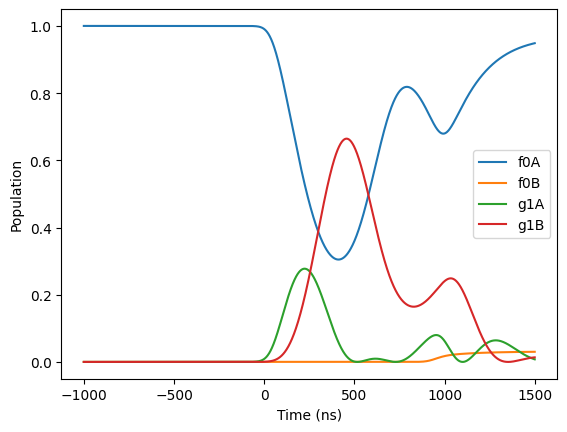

10.0%. Run time:   0.22s. Est. time left: 00:00:00:01
20.0%. Run time:   0.45s. Est. time left: 00:00:00:01
30.0%. Run time:   0.67s. Est. time left: 00:00:00:01
40.0%. Run time:   0.88s. Est. time left: 00:00:00:01
50.0%. Run time:   1.12s. Est. time left: 00:00:00:01
60.0%. Run time:   1.34s. Est. time left: 00:00:00:00
70.0%. Run time:   1.65s. Est. time left: 00:00:00:00
80.0%. Run time:  13.60s. Est. time left: 00:00:00:03
90.0%. Run time:  15.18s. Est. time left: 00:00:00:01
100.0%. Run time:  15.42s. Est. time left: 00:00:00:00
Total run time:  15.42s


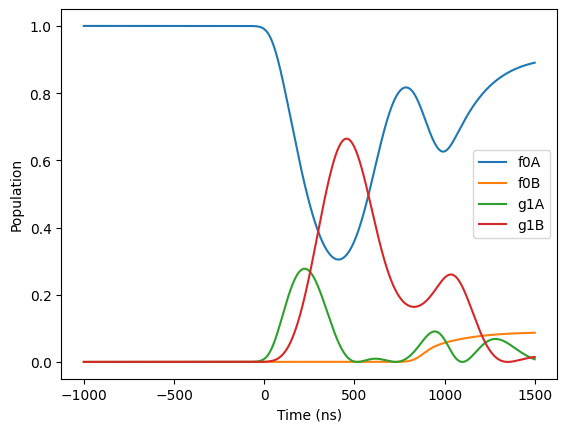

10.0%. Run time:   0.24s. Est. time left: 00:00:00:02
20.0%. Run time:   0.46s. Est. time left: 00:00:00:01
30.0%. Run time:   0.69s. Est. time left: 00:00:00:01
40.0%. Run time:   0.91s. Est. time left: 00:00:00:01
50.0%. Run time:   1.25s. Est. time left: 00:00:00:01
60.0%. Run time:   1.49s. Est. time left: 00:00:00:00
70.0%. Run time:   1.77s. Est. time left: 00:00:00:00
80.0%. Run time:  12.18s. Est. time left: 00:00:00:03
90.0%. Run time:  13.84s. Est. time left: 00:00:00:01
100.0%. Run time:  14.06s. Est. time left: 00:00:00:00
Total run time:  14.06s


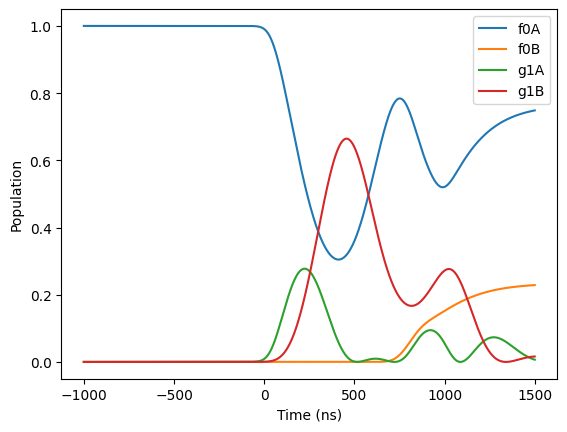

10.0%. Run time:   0.26s. Est. time left: 00:00:00:02
20.0%. Run time:   0.48s. Est. time left: 00:00:00:01
30.0%. Run time:   0.70s. Est. time left: 00:00:00:01
40.0%. Run time:   0.93s. Est. time left: 00:00:00:01
50.0%. Run time:   1.16s. Est. time left: 00:00:00:01
60.0%. Run time:   1.38s. Est. time left: 00:00:00:00
70.0%. Run time:   1.63s. Est. time left: 00:00:00:00
80.0%. Run time:  11.79s. Est. time left: 00:00:00:02
90.0%. Run time:  13.59s. Est. time left: 00:00:00:01
100.0%. Run time:  13.82s. Est. time left: 00:00:00:00
Total run time:  13.82s


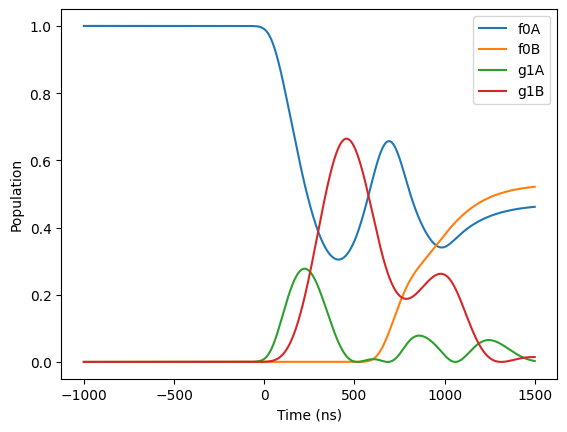

10.0%. Run time:   0.21s. Est. time left: 00:00:00:01
20.0%. Run time:   0.45s. Est. time left: 00:00:00:01
30.0%. Run time:   0.66s. Est. time left: 00:00:00:01
40.0%. Run time:   0.90s. Est. time left: 00:00:00:01
50.0%. Run time:   1.11s. Est. time left: 00:00:00:01
60.0%. Run time:   1.35s. Est. time left: 00:00:00:00
70.0%. Run time:   1.56s. Est. time left: 00:00:00:00
80.0%. Run time:  15.43s. Est. time left: 00:00:00:03
90.0%. Run time:  17.31s. Est. time left: 00:00:00:01
100.0%. Run time:  17.53s. Est. time left: 00:00:00:00
Total run time:  17.53s


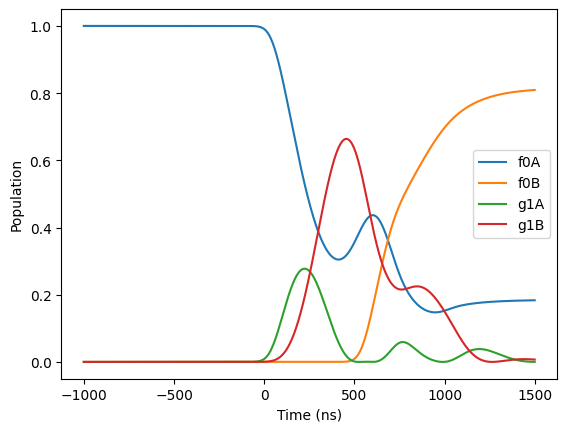

10.0%. Run time:   0.25s. Est. time left: 00:00:00:02
20.0%. Run time:   0.49s. Est. time left: 00:00:00:01
30.0%. Run time:   0.73s. Est. time left: 00:00:00:01
40.0%. Run time:   0.96s. Est. time left: 00:00:00:01
50.0%. Run time:   1.18s. Est. time left: 00:00:00:01
60.0%. Run time:   1.41s. Est. time left: 00:00:00:00
70.0%. Run time:   1.63s. Est. time left: 00:00:00:00
80.0%. Run time:  13.77s. Est. time left: 00:00:00:03
90.0%. Run time:  15.17s. Est. time left: 00:00:00:01
100.0%. Run time:  15.39s. Est. time left: 00:00:00:00
Total run time:  15.39s


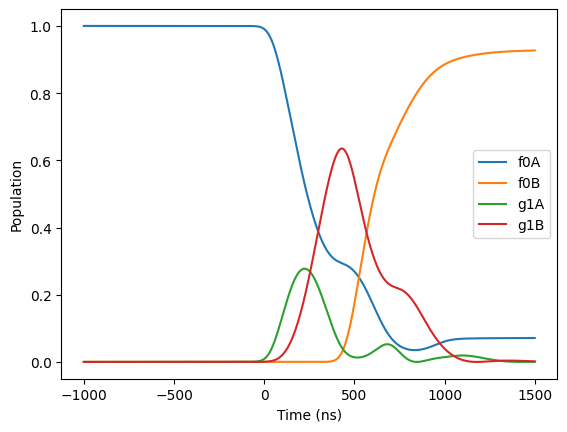

10.0%. Run time:   0.22s. Est. time left: 00:00:00:01
20.0%. Run time:   0.45s. Est. time left: 00:00:00:01
30.0%. Run time:   0.67s. Est. time left: 00:00:00:01
40.0%. Run time:   0.88s. Est. time left: 00:00:00:01
50.0%. Run time:   1.12s. Est. time left: 00:00:00:01
60.0%. Run time:   1.35s. Est. time left: 00:00:00:00
70.0%. Run time:   1.57s. Est. time left: 00:00:00:00
80.0%. Run time:   8.69s. Est. time left: 00:00:00:02
90.0%. Run time:  10.08s. Est. time left: 00:00:00:01
100.0%. Run time:  10.31s. Est. time left: 00:00:00:00
Total run time:  10.31s


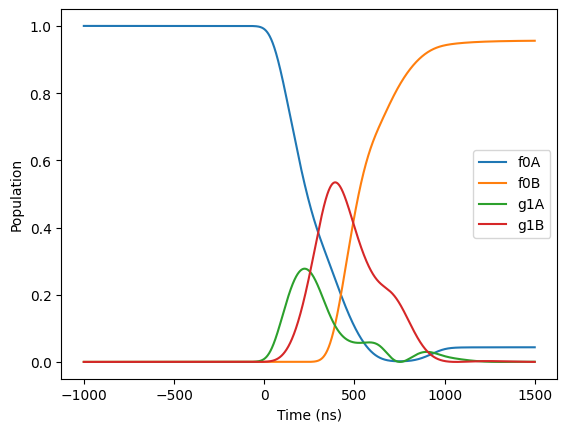

10.0%. Run time:   0.23s. Est. time left: 00:00:00:02
20.0%. Run time:   0.45s. Est. time left: 00:00:00:01
30.0%. Run time:   0.66s. Est. time left: 00:00:00:01
40.0%. Run time:   0.89s. Est. time left: 00:00:00:01
50.0%. Run time:   1.11s. Est. time left: 00:00:00:01
60.0%. Run time:   1.34s. Est. time left: 00:00:00:00
70.0%. Run time:   1.56s. Est. time left: 00:00:00:00
80.0%. Run time:   9.35s. Est. time left: 00:00:00:02
90.0%. Run time:  10.89s. Est. time left: 00:00:00:01
100.0%. Run time:  11.13s. Est. time left: 00:00:00:00
Total run time:  11.13s


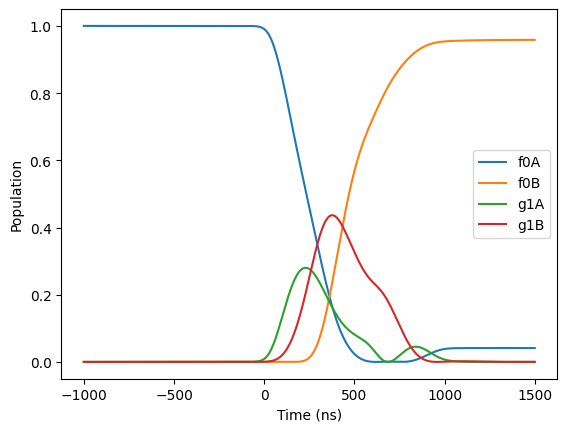

10.0%. Run time:   0.24s. Est. time left: 00:00:00:02
20.0%. Run time:   0.46s. Est. time left: 00:00:00:01
30.0%. Run time:   0.69s. Est. time left: 00:00:00:01
40.0%. Run time:   0.91s. Est. time left: 00:00:00:01
50.0%. Run time:   1.13s. Est. time left: 00:00:00:01
60.0%. Run time:   1.38s. Est. time left: 00:00:00:00
70.0%. Run time:   1.65s. Est. time left: 00:00:00:00
80.0%. Run time:  11.31s. Est. time left: 00:00:00:02
90.0%. Run time:  13.42s. Est. time left: 00:00:00:01
100.0%. Run time:  13.64s. Est. time left: 00:00:00:00
Total run time:  13.64s


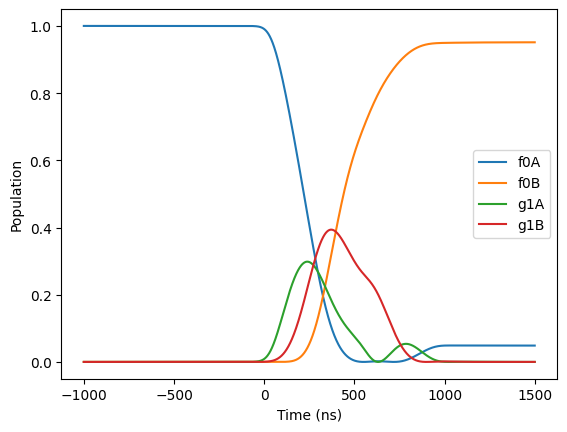

10.0%. Run time:   0.24s. Est. time left: 00:00:00:02
20.0%. Run time:   0.50s. Est. time left: 00:00:00:02
30.0%. Run time:   0.74s. Est. time left: 00:00:00:01
40.0%. Run time:   0.97s. Est. time left: 00:00:00:01
50.0%. Run time:   1.19s. Est. time left: 00:00:00:01
60.0%. Run time:   1.41s. Est. time left: 00:00:00:00
70.0%. Run time:   1.65s. Est. time left: 00:00:00:00
80.0%. Run time:  18.46s. Est. time left: 00:00:00:04
90.0%. Run time:  20.09s. Est. time left: 00:00:00:02
100.0%. Run time:  20.31s. Est. time left: 00:00:00:00
Total run time:  20.31s


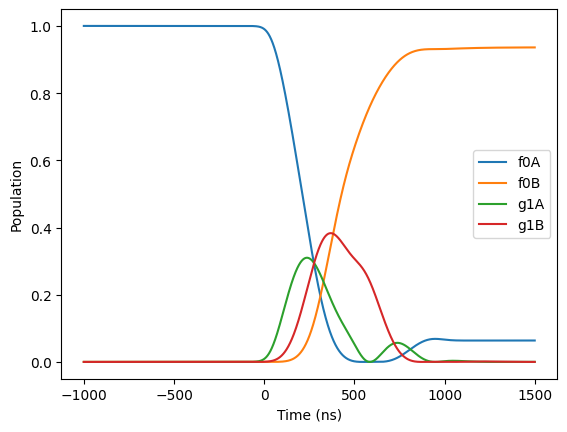

10.0%. Run time:   0.25s. Est. time left: 00:00:00:02
20.0%. Run time:   0.47s. Est. time left: 00:00:00:01
30.0%. Run time:   0.69s. Est. time left: 00:00:00:01
40.0%. Run time:   0.92s. Est. time left: 00:00:00:01
50.0%. Run time:   1.14s. Est. time left: 00:00:00:01
60.0%. Run time:   1.37s. Est. time left: 00:00:00:00
70.0%. Run time:   1.58s. Est. time left: 00:00:00:00
80.0%. Run time:  30.06s. Est. time left: 00:00:00:07
90.0%. Run time:  31.68s. Est. time left: 00:00:00:03
100.0%. Run time:  31.91s. Est. time left: 00:00:00:00
Total run time:  31.91s


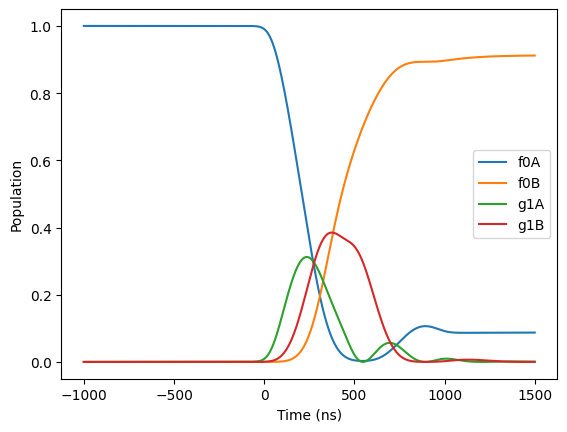

10.0%. Run time:   0.23s. Est. time left: 00:00:00:02
20.0%. Run time:   0.50s. Est. time left: 00:00:00:01
30.0%. Run time:   0.75s. Est. time left: 00:00:00:01
40.0%. Run time:   0.98s. Est. time left: 00:00:00:01
50.0%. Run time:   1.20s. Est. time left: 00:00:00:01
60.0%. Run time:   1.43s. Est. time left: 00:00:00:00
70.0%. Run time:   1.66s. Est. time left: 00:00:00:00
80.0%. Run time:  19.33s. Est. time left: 00:00:00:04
90.0%. Run time:  20.81s. Est. time left: 00:00:00:02
100.0%. Run time:  21.04s. Est. time left: 00:00:00:00
Total run time:  21.04s


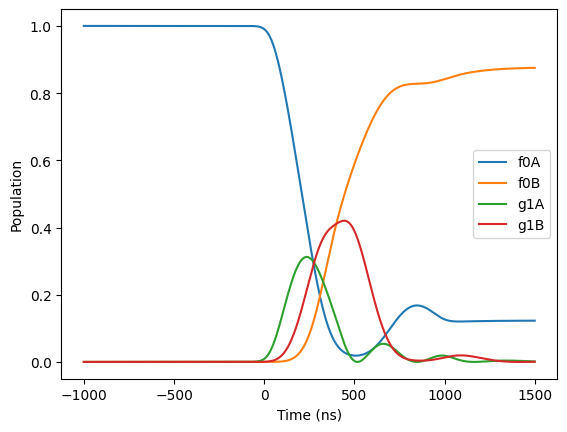

10.0%. Run time:   0.24s. Est. time left: 00:00:00:02
20.0%. Run time:   0.52s. Est. time left: 00:00:00:02
30.0%. Run time:   0.78s. Est. time left: 00:00:00:01
40.0%. Run time:   1.03s. Est. time left: 00:00:00:01
50.0%. Run time:   1.26s. Est. time left: 00:00:00:01
60.0%. Run time:   1.47s. Est. time left: 00:00:00:00
70.0%. Run time:   1.70s. Est. time left: 00:00:00:00
80.0%. Run time:  14.96s. Est. time left: 00:00:00:03
90.0%. Run time:  16.56s. Est. time left: 00:00:00:01
100.0%. Run time:  16.79s. Est. time left: 00:00:00:00
Total run time:  16.79s


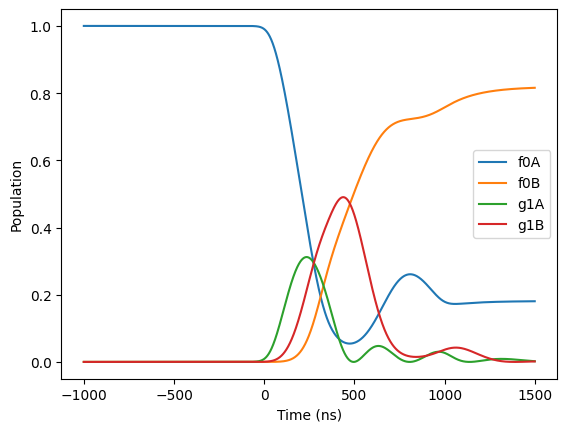

10.0%. Run time:   0.24s. Est. time left: 00:00:00:02
20.0%. Run time:   0.46s. Est. time left: 00:00:00:01
30.0%. Run time:   0.69s. Est. time left: 00:00:00:01
40.0%. Run time:   0.92s. Est. time left: 00:00:00:01
50.0%. Run time:   1.14s. Est. time left: 00:00:00:01
60.0%. Run time:   1.35s. Est. time left: 00:00:00:00
70.0%. Run time:   1.59s. Est. time left: 00:00:00:00
80.0%. Run time:  14.56s. Est. time left: 00:00:00:03
90.0%. Run time:  16.13s. Est. time left: 00:00:00:01
100.0%. Run time:  16.36s. Est. time left: 00:00:00:00
Total run time:  16.36s


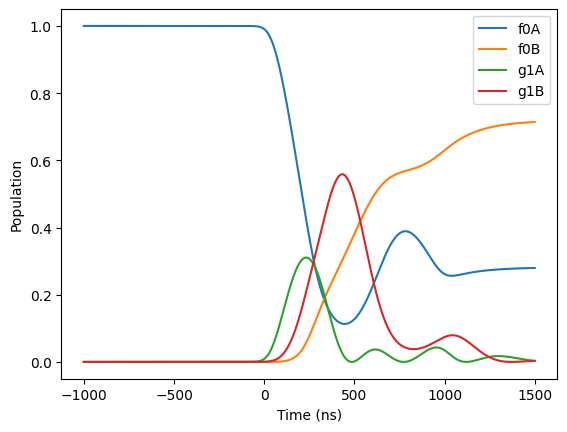

10.0%. Run time:   0.29s. Est. time left: 00:00:00:02
20.0%. Run time:   0.56s. Est. time left: 00:00:00:02
30.0%. Run time:   0.80s. Est. time left: 00:00:00:01
40.0%. Run time:   1.04s. Est. time left: 00:00:00:01
50.0%. Run time:   1.27s. Est. time left: 00:00:00:01
60.0%. Run time:   1.51s. Est. time left: 00:00:00:01
70.0%. Run time:   1.81s. Est. time left: 00:00:00:00
80.0%. Run time:  15.72s. Est. time left: 00:00:00:03
90.0%. Run time:  17.30s. Est. time left: 00:00:00:01
100.0%. Run time:  17.51s. Est. time left: 00:00:00:00
Total run time:  17.51s


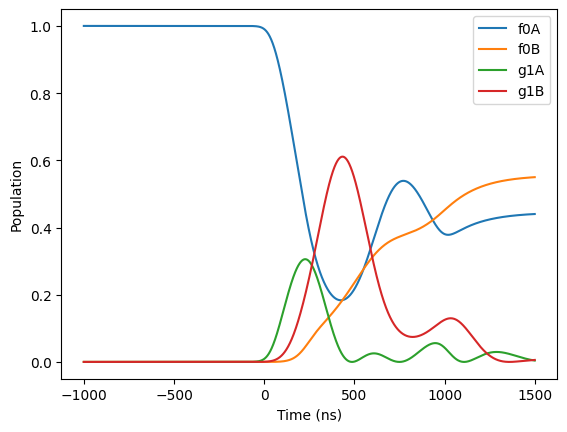

10.0%. Run time:   0.25s. Est. time left: 00:00:00:02
20.0%. Run time:   0.49s. Est. time left: 00:00:00:01
30.0%. Run time:   0.72s. Est. time left: 00:00:00:01
40.0%. Run time:   0.93s. Est. time left: 00:00:00:01
50.0%. Run time:   1.15s. Est. time left: 00:00:00:01
60.0%. Run time:   1.36s. Est. time left: 00:00:00:00
70.0%. Run time:   1.67s. Est. time left: 00:00:00:00
80.0%. Run time:  13.10s. Est. time left: 00:00:00:03
90.0%. Run time:  14.64s. Est. time left: 00:00:00:01
100.0%. Run time:  14.87s. Est. time left: 00:00:00:00
Total run time:  14.87s


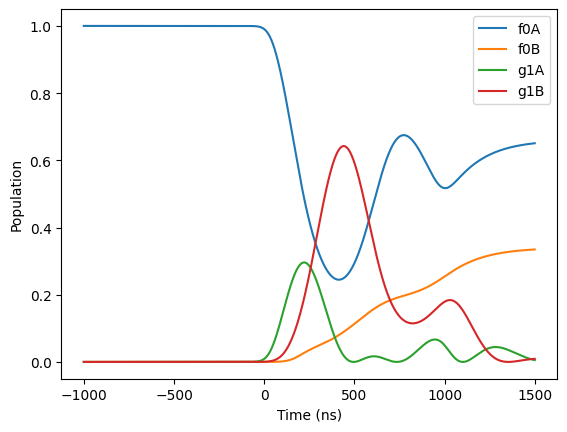

10.0%. Run time:   0.29s. Est. time left: 00:00:00:02
20.0%. Run time:   0.52s. Est. time left: 00:00:00:02
30.0%. Run time:   0.73s. Est. time left: 00:00:00:01
40.0%. Run time:   0.94s. Est. time left: 00:00:00:01
50.0%. Run time:   1.16s. Est. time left: 00:00:00:01
60.0%. Run time:   1.37s. Est. time left: 00:00:00:00
70.0%. Run time:   1.68s. Est. time left: 00:00:00:00
80.0%. Run time:  13.51s. Est. time left: 00:00:00:03
90.0%. Run time:  15.21s. Est. time left: 00:00:00:01
100.0%. Run time:  15.48s. Est. time left: 00:00:00:00
Total run time:  15.48s


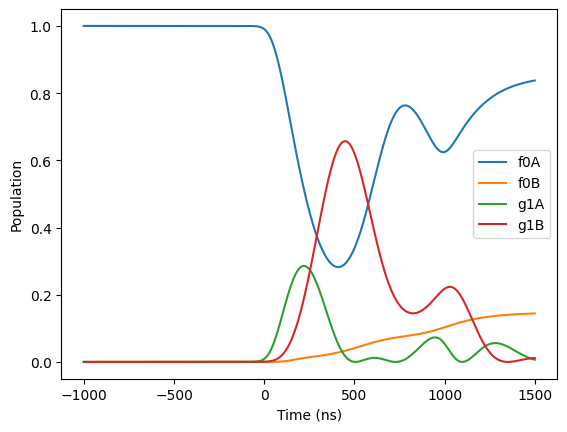

10.0%. Run time:   0.24s. Est. time left: 00:00:00:02
20.0%. Run time:   0.52s. Est. time left: 00:00:00:02
30.0%. Run time:   0.85s. Est. time left: 00:00:00:01
40.0%. Run time:   1.08s. Est. time left: 00:00:00:01
50.0%. Run time:   1.33s. Est. time left: 00:00:00:01
60.0%. Run time:   1.57s. Est. time left: 00:00:00:01
70.0%. Run time:   1.88s. Est. time left: 00:00:00:00
80.0%. Run time:  14.10s. Est. time left: 00:00:00:03
90.0%. Run time:  15.71s. Est. time left: 00:00:00:01
100.0%. Run time:  15.95s. Est. time left: 00:00:00:00
Total run time:  15.95s


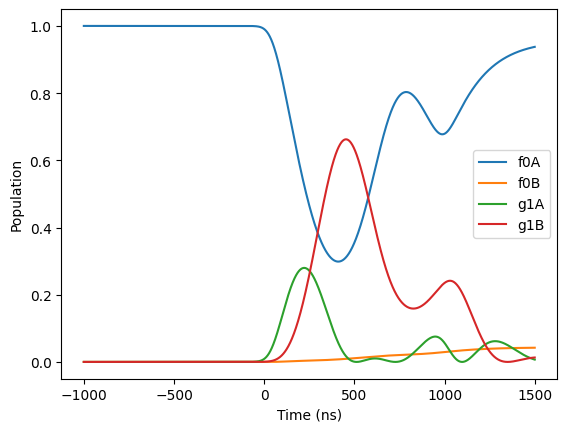

10.0%. Run time:   0.23s. Est. time left: 00:00:00:02
20.0%. Run time:   0.44s. Est. time left: 00:00:00:01
30.0%. Run time:   0.67s. Est. time left: 00:00:00:01
40.0%. Run time:   0.89s. Est. time left: 00:00:00:01
50.0%. Run time:   1.11s. Est. time left: 00:00:00:01
60.0%. Run time:   1.33s. Est. time left: 00:00:00:00
70.0%. Run time:   1.60s. Est. time left: 00:00:00:00
80.0%. Run time:  13.65s. Est. time left: 00:00:00:03
90.0%. Run time:  15.34s. Est. time left: 00:00:00:01
100.0%. Run time:  15.57s. Est. time left: 00:00:00:00
Total run time:  15.58s


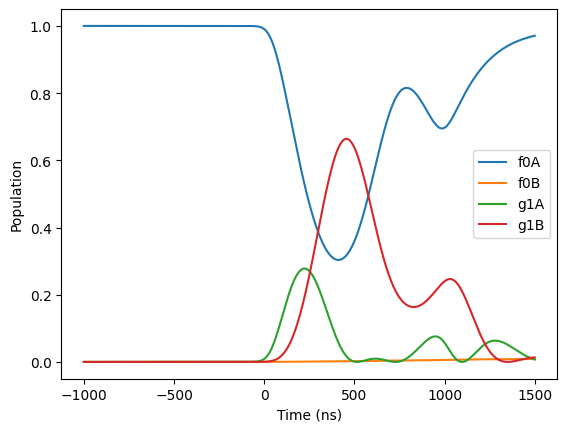

10.0%. Run time:   0.24s. Est. time left: 00:00:00:02
20.0%. Run time:   0.47s. Est. time left: 00:00:00:01
30.0%. Run time:   0.70s. Est. time left: 00:00:00:01
40.0%. Run time:   0.93s. Est. time left: 00:00:00:01
50.0%. Run time:   1.15s. Est. time left: 00:00:00:01
60.0%. Run time:   1.37s. Est. time left: 00:00:00:00
70.0%. Run time:   1.71s. Est. time left: 00:00:00:00
80.0%. Run time:  14.08s. Est. time left: 00:00:00:03
90.0%. Run time:  15.81s. Est. time left: 00:00:00:01
100.0%. Run time:  16.03s. Est. time left: 00:00:00:00
Total run time:  16.03s


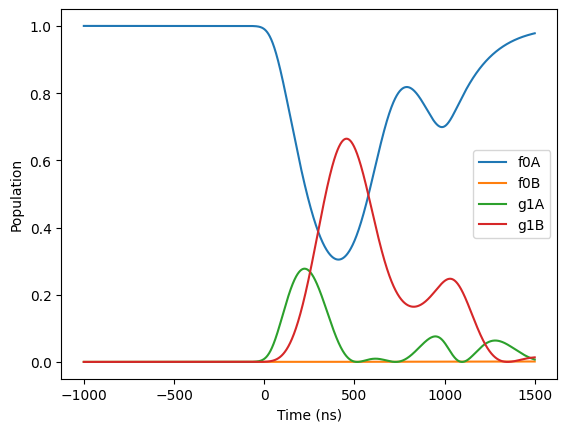

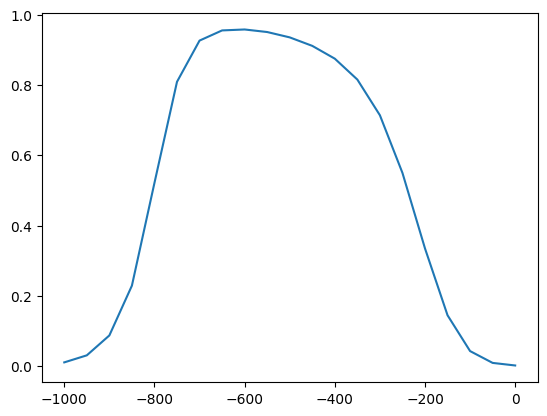

In [47]:
def H(t, args):
    return H_fogi_A(t, args)+H_fogi_B(t, args)+H_c(t, args)

# def c_ops(t, args):
#     return np.sqrt(args["kappa_A"]*args["eta"])*a_A +  np.sqrt(args["kappa_B"])*a_B

eta = 1
const = 2.5e-3 * 2 * np.pi
kappa_A = 0.001 * 2 * np.pi
kappa_B = 0.001 * 2 * np.pi
mode_A = "sech_0"
mode_B = "sech_0"
delay = np.linspace(-1000, 0, 21)

c_ops = []
e_ops = [f0_A.proj(), f0_B.proj(), g1_A.proj(), g1_B.proj()]
e_labels = ["f0A", "f0B", "g1A", "g1B"]
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=3000, max_step=0.5, store_states=False)
psi0 = f0_A
t = np.linspace(-1000, 1500, 2501)

f0B = []
def result(delay):   
    for tau in delay:
        result = qt.mesolve(
            H, psi0, t, c_ops, e_ops,
            args={"center_A":0, "center_B":tau, "eta":eta, "time0":t[0], "const":const, "kappa_A":kappa_A, "kappa_B":kappa_B, "mode_A":mode_A, "mode_B":mode_B},
            options=options, progress_bar=True
        )
        fig = plt.figure()
        ax = fig.add_subplot(1, 1, 1)
        for i, l in enumerate(e_labels):
            exp = np.abs(result.expect[i])
            ax.plot(t, exp, label=l)
            if i == 1:
                f0B.append(exp[-1])
        ax.legend()
        ax.set_xlabel("Time (ns)") ;ax.set_ylabel("Population")
        plt.show()
    return f0B

plt.plot(delay, result(delay))

c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:   1.25s. Est. time left: 00:00:00:11
20.0%. Run time:   2.51s. Est. time left: 00:00:00:10
30.0%. Run time:   3.74s. Est. time left: 00:00:00:08
40.0%. Run time:   4.95s. Est. time left: 00:00:00:07
50.0%. Run time:   6.15s. Est. time left: 00:00:00:06
60.0%. Run time:   7.35s. Est. time left: 00:00:00:04
70.0%. Run time:   9.34s. Est. time left: 00:00:00:04
80.0%. Run time: 101.30s. Est. time left: 00:00:00:25
90.0%. Run time: 119.24s. Est. time left: 00:00:00:13
100.0%. Run time: 120.62s. Est. time left: 00:00:00:00
Total run time: 120.63s


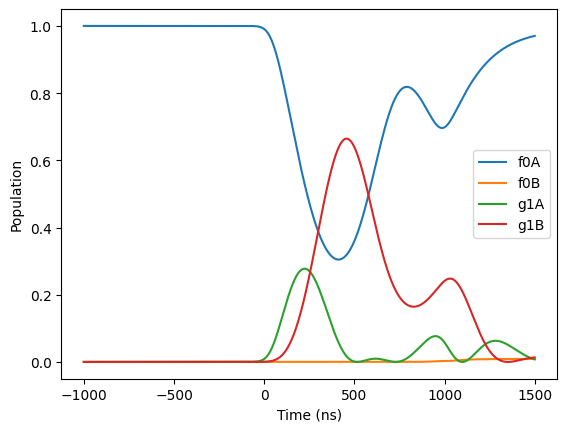

10.0%. Run time:   1.75s. Est. time left: 00:00:00:15
20.0%. Run time:   3.44s. Est. time left: 00:00:00:13
30.0%. Run time:   5.15s. Est. time left: 00:00:00:12
40.0%. Run time:   6.85s. Est. time left: 00:00:00:10
50.0%. Run time:   8.56s. Est. time left: 00:00:00:08
60.0%. Run time:  10.37s. Est. time left: 00:00:00:06
70.0%. Run time:  13.02s. Est. time left: 00:00:00:05
80.0%. Run time: 167.77s. Est. time left: 00:00:00:41
90.0%. Run time: 184.94s. Est. time left: 00:00:00:20
100.0%. Run time: 186.90s. Est. time left: 00:00:00:00
Total run time: 186.90s


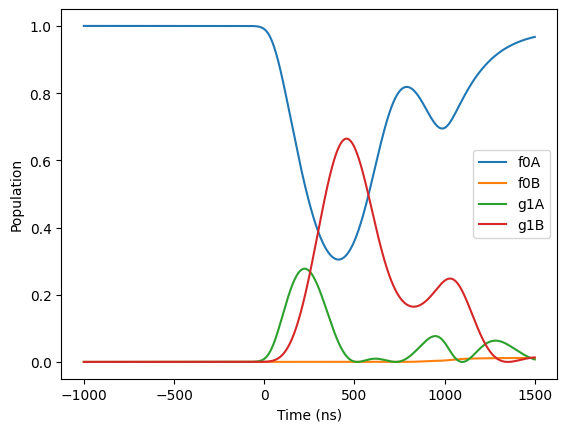

10.0%. Run time:   1.63s. Est. time left: 00:00:00:14
20.0%. Run time:   3.27s. Est. time left: 00:00:00:13
30.0%. Run time:   4.91s. Est. time left: 00:00:00:11
40.0%. Run time:   6.56s. Est. time left: 00:00:00:09
50.0%. Run time:   8.20s. Est. time left: 00:00:00:08
60.0%. Run time:   9.90s. Est. time left: 00:00:00:06
70.0%. Run time:  12.24s. Est. time left: 00:00:00:05
80.0%. Run time: 151.00s. Est. time left: 00:00:00:37
90.0%. Run time: 165.74s. Est. time left: 00:00:00:18
100.0%. Run time: 167.59s. Est. time left: 00:00:00:00
Total run time: 167.59s


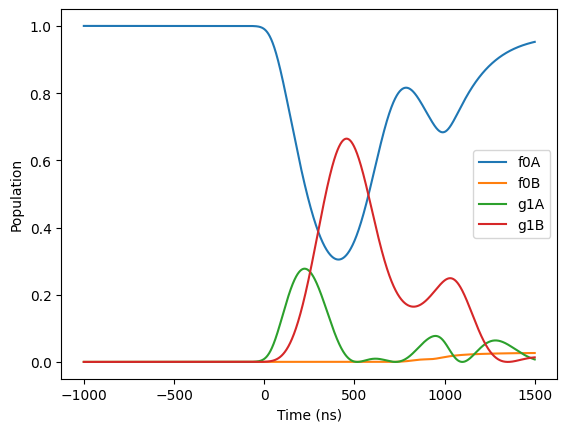

10.0%. Run time:   1.60s. Est. time left: 00:00:00:14
20.0%. Run time:   3.16s. Est. time left: 00:00:00:12
30.0%. Run time:   4.74s. Est. time left: 00:00:00:11
40.0%. Run time:   6.32s. Est. time left: 00:00:00:09
50.0%. Run time:   7.89s. Est. time left: 00:00:00:07
60.0%. Run time:   9.48s. Est. time left: 00:00:00:06
70.0%. Run time:  11.65s. Est. time left: 00:00:00:04
80.0%. Run time: 124.38s. Est. time left: 00:00:00:31
90.0%. Run time: 138.68s. Est. time left: 00:00:00:15
100.0%. Run time: 140.43s. Est. time left: 00:00:00:00
Total run time: 140.43s


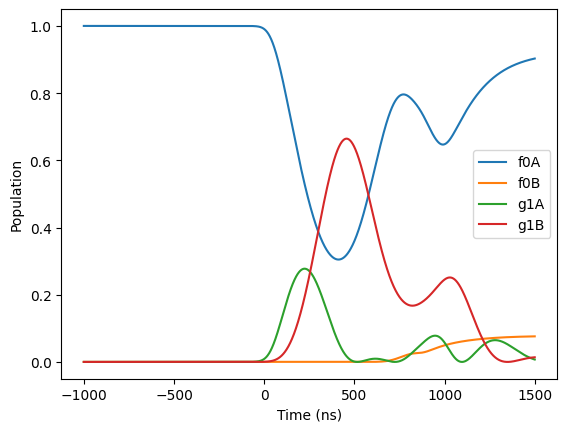

10.0%. Run time:   1.53s. Est. time left: 00:00:00:13
20.0%. Run time:   3.06s. Est. time left: 00:00:00:12
30.0%. Run time:   4.62s. Est. time left: 00:00:00:10
40.0%. Run time:   6.17s. Est. time left: 00:00:00:09
50.0%. Run time:   7.69s. Est. time left: 00:00:00:07
60.0%. Run time:   9.27s. Est. time left: 00:00:00:06
70.0%. Run time:  11.32s. Est. time left: 00:00:00:04
80.0%. Run time: 112.99s. Est. time left: 00:00:00:28
90.0%. Run time: 126.97s. Est. time left: 00:00:00:14
100.0%. Run time: 128.69s. Est. time left: 00:00:00:00
Total run time: 128.69s


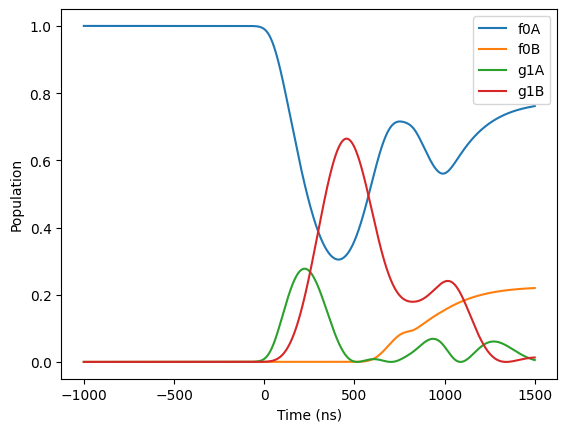

10.0%. Run time:   1.55s. Est. time left: 00:00:00:13
20.0%. Run time:   3.08s. Est. time left: 00:00:00:12
30.0%. Run time:   4.65s. Est. time left: 00:00:00:10
40.0%. Run time:   6.18s. Est. time left: 00:00:00:09
50.0%. Run time:   7.71s. Est. time left: 00:00:00:07
60.0%. Run time:   9.29s. Est. time left: 00:00:00:06
70.0%. Run time:  11.16s. Est. time left: 00:00:00:04
80.0%. Run time: 115.01s. Est. time left: 00:00:00:28
90.0%. Run time: 129.97s. Est. time left: 00:00:00:14
100.0%. Run time: 131.68s. Est. time left: 00:00:00:00
Total run time: 131.68s


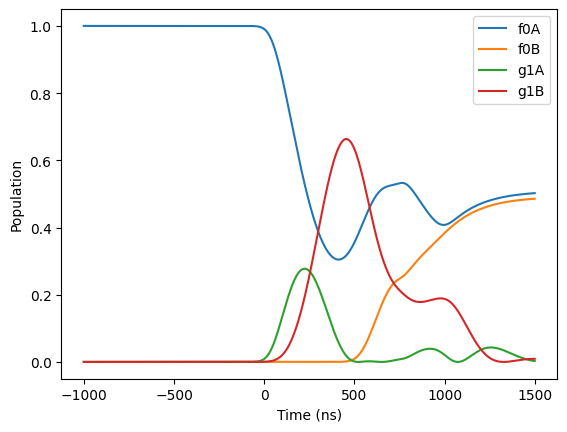

10.0%. Run time:   1.55s. Est. time left: 00:00:00:13
20.0%. Run time:   3.06s. Est. time left: 00:00:00:12
30.0%. Run time:   4.57s. Est. time left: 00:00:00:10
40.0%. Run time:   6.10s. Est. time left: 00:00:00:09
50.0%. Run time:   7.64s. Est. time left: 00:00:00:07
60.0%. Run time:   9.19s. Est. time left: 00:00:00:06
70.0%. Run time:  11.33s. Est. time left: 00:00:00:04
80.0%. Run time: 144.77s. Est. time left: 00:00:00:36
90.0%. Run time: 160.44s. Est. time left: 00:00:00:17
100.0%. Run time: 162.13s. Est. time left: 00:00:00:00
Total run time: 162.13s


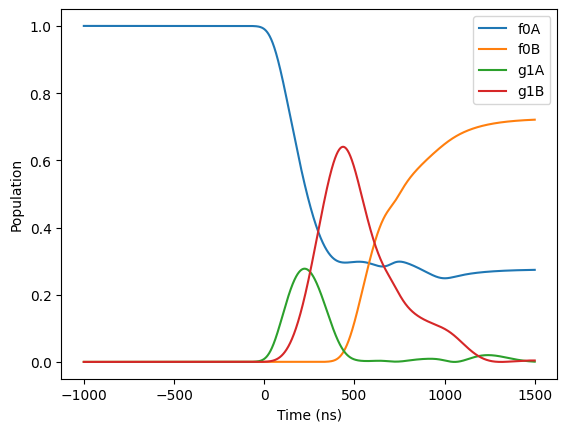

10.0%. Run time:   1.53s. Est. time left: 00:00:00:13
20.0%. Run time:   3.04s. Est. time left: 00:00:00:12
30.0%. Run time:   4.55s. Est. time left: 00:00:00:10
40.0%. Run time:   6.06s. Est. time left: 00:00:00:09
50.0%. Run time:   7.54s. Est. time left: 00:00:00:07
60.0%. Run time:   9.11s. Est. time left: 00:00:00:06
70.0%. Run time:  11.27s. Est. time left: 00:00:00:04
80.0%. Run time: 340.27s. Est. time left: 00:00:01:25
90.0%. Run time: 356.30s. Est. time left: 00:00:00:39
100.0%. Run time: 357.98s. Est. time left: 00:00:00:00
Total run time: 357.98s


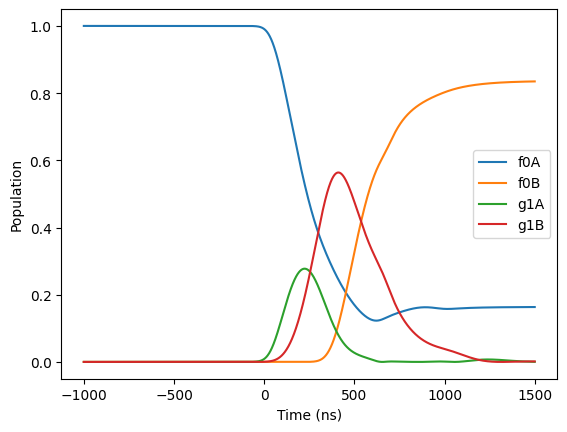

10.0%. Run time:   1.50s. Est. time left: 00:00:00:13
20.0%. Run time:   2.99s. Est. time left: 00:00:00:11
30.0%. Run time:   4.53s. Est. time left: 00:00:00:10
40.0%. Run time:   6.01s. Est. time left: 00:00:00:09
50.0%. Run time:   7.54s. Est. time left: 00:00:00:07
60.0%. Run time:   9.09s. Est. time left: 00:00:00:06
70.0%. Run time:  11.19s. Est. time left: 00:00:00:04
80.0%. Run time: 280.02s. Est. time left: 00:00:01:10
90.0%. Run time: 295.18s. Est. time left: 00:00:00:32
100.0%. Run time: 296.87s. Est. time left: 00:00:00:00
Total run time: 296.87s


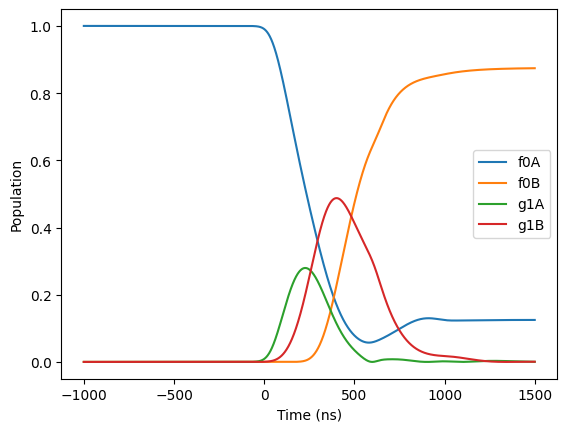

10.0%. Run time:   1.47s. Est. time left: 00:00:00:13
20.0%. Run time:   2.99s. Est. time left: 00:00:00:11
30.0%. Run time:   4.47s. Est. time left: 00:00:00:10
40.0%. Run time:   6.03s. Est. time left: 00:00:00:09
50.0%. Run time:   7.57s. Est. time left: 00:00:00:07
60.0%. Run time:   9.16s. Est. time left: 00:00:00:06
70.0%. Run time:  11.23s. Est. time left: 00:00:00:04
80.0%. Run time: 274.35s. Est. time left: 00:00:01:08
90.0%. Run time: 287.90s. Est. time left: 00:00:00:31
100.0%. Run time: 289.56s. Est. time left: 00:00:00:00
Total run time: 289.56s


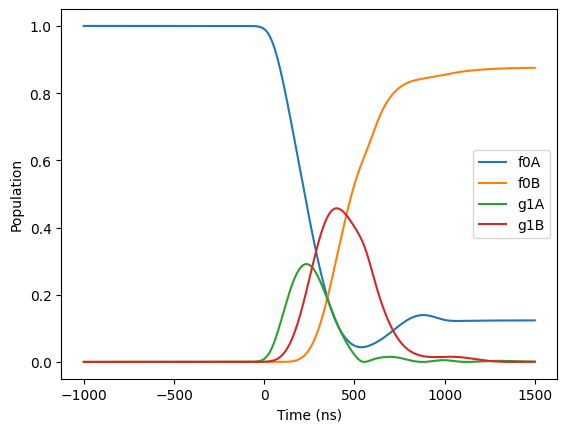

10.0%. Run time:   1.50s. Est. time left: 00:00:00:13
20.0%. Run time:   3.01s. Est. time left: 00:00:00:12
30.0%. Run time:   4.49s. Est. time left: 00:00:00:10
40.0%. Run time:   6.02s. Est. time left: 00:00:00:09
50.0%. Run time:   7.55s. Est. time left: 00:00:00:07
60.0%. Run time:   9.32s. Est. time left: 00:00:00:06
70.0%. Run time:  11.28s. Est. time left: 00:00:00:04
80.0%. Run time: 172.32s. Est. time left: 00:00:00:43
90.0%. Run time: 185.04s. Est. time left: 00:00:00:20
100.0%. Run time: 186.70s. Est. time left: 00:00:00:00
Total run time: 186.70s


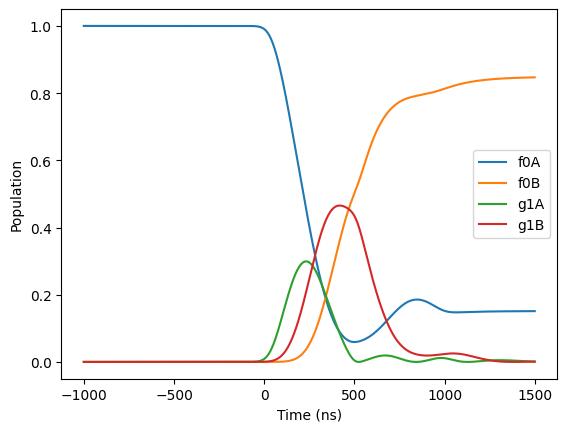

10.0%. Run time:   1.55s. Est. time left: 00:00:00:13
20.0%. Run time:   3.06s. Est. time left: 00:00:00:12
30.0%. Run time:   4.56s. Est. time left: 00:00:00:10
40.0%. Run time:   6.05s. Est. time left: 00:00:00:09
50.0%. Run time:   7.56s. Est. time left: 00:00:00:07
60.0%. Run time:   9.54s. Est. time left: 00:00:00:06
70.0%. Run time:  11.32s. Est. time left: 00:00:00:04
80.0%. Run time: 131.25s. Est. time left: 00:00:00:32
90.0%. Run time: 143.42s. Est. time left: 00:00:00:15
100.0%. Run time: 145.08s. Est. time left: 00:00:00:00
Total run time: 145.08s


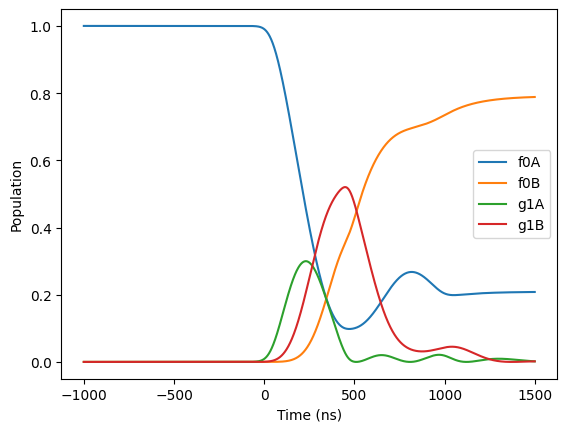

10.0%. Run time:   1.53s. Est. time left: 00:00:00:13
20.0%. Run time:   3.03s. Est. time left: 00:00:00:12
30.0%. Run time:   4.53s. Est. time left: 00:00:00:10
40.0%. Run time:   6.00s. Est. time left: 00:00:00:08
50.0%. Run time:   7.57s. Est. time left: 00:00:00:07
60.0%. Run time:   9.61s. Est. time left: 00:00:00:06
70.0%. Run time:  11.44s. Est. time left: 00:00:00:04
80.0%. Run time: 116.26s. Est. time left: 00:00:00:29
90.0%. Run time: 128.68s. Est. time left: 00:00:00:14
100.0%. Run time: 130.33s. Est. time left: 00:00:00:00
Total run time: 130.33s


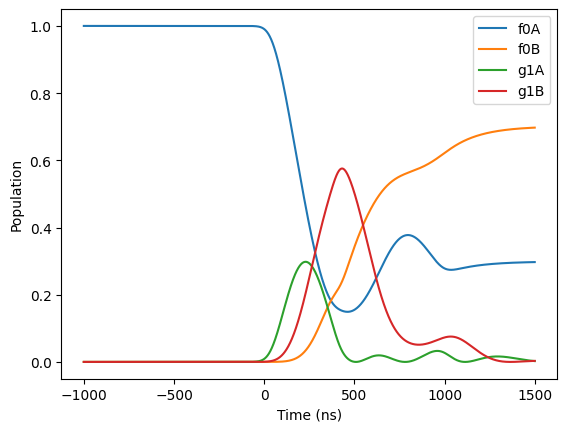

10.0%. Run time:   1.53s. Est. time left: 00:00:00:13
20.0%. Run time:   3.00s. Est. time left: 00:00:00:11
30.0%. Run time:   4.47s. Est. time left: 00:00:00:10
40.0%. Run time:   6.06s. Est. time left: 00:00:00:09
50.0%. Run time:   7.58s. Est. time left: 00:00:00:07
60.0%. Run time:   9.71s. Est. time left: 00:00:00:06
70.0%. Run time:  11.56s. Est. time left: 00:00:00:04
80.0%. Run time: 111.61s. Est. time left: 00:00:00:27
90.0%. Run time: 124.05s. Est. time left: 00:00:00:13
100.0%. Run time: 125.74s. Est. time left: 00:00:00:00
Total run time: 125.74s


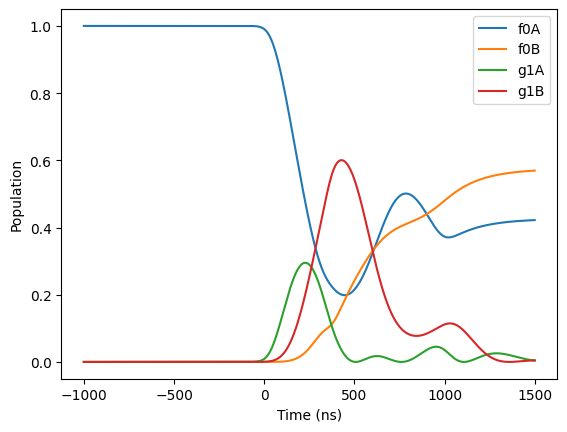

10.0%. Run time:   1.60s. Est. time left: 00:00:00:14
20.0%. Run time:   3.09s. Est. time left: 00:00:00:12
30.0%. Run time:   4.60s. Est. time left: 00:00:00:10
40.0%. Run time:   6.11s. Est. time left: 00:00:00:09
50.0%. Run time:   7.70s. Est. time left: 00:00:00:07
60.0%. Run time:   9.76s. Est. time left: 00:00:00:06
70.0%. Run time:  12.24s. Est. time left: 00:00:00:05
80.0%. Run time: 109.17s. Est. time left: 00:00:00:27
90.0%. Run time: 122.17s. Est. time left: 00:00:00:13
100.0%. Run time: 123.88s. Est. time left: 00:00:00:00
Total run time: 123.88s


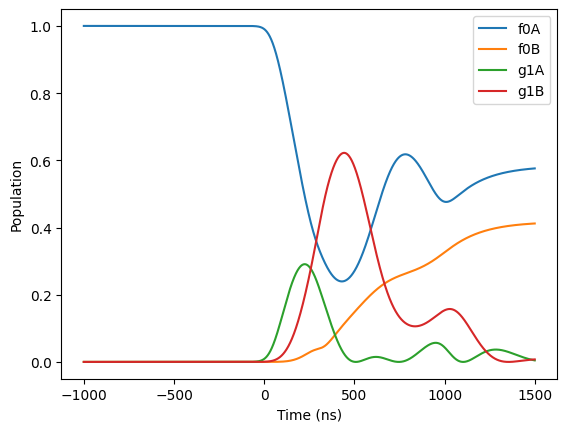

10.0%. Run time:   1.48s. Est. time left: 00:00:00:13
20.0%. Run time:   2.93s. Est. time left: 00:00:00:11
30.0%. Run time:   4.43s. Est. time left: 00:00:00:10
40.0%. Run time:   5.93s. Est. time left: 00:00:00:08
50.0%. Run time:   7.69s. Est. time left: 00:00:00:07
60.0%. Run time:   9.61s. Est. time left: 00:00:00:06
70.0%. Run time:  11.97s. Est. time left: 00:00:00:05
80.0%. Run time: 104.48s. Est. time left: 00:00:00:26
90.0%. Run time: 117.05s. Est. time left: 00:00:00:13
100.0%. Run time: 118.72s. Est. time left: 00:00:00:00
Total run time: 118.72s


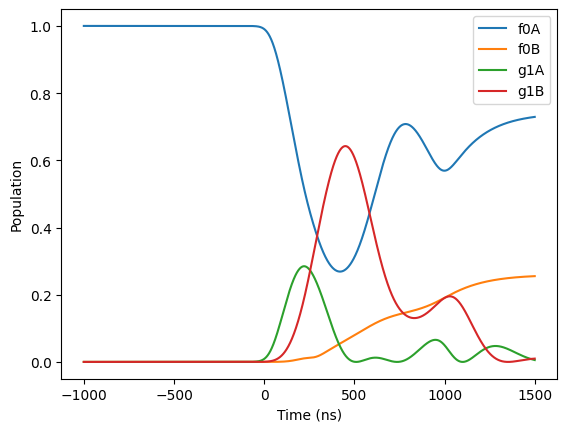

10.0%. Run time:   1.48s. Est. time left: 00:00:00:13
20.0%. Run time:   2.96s. Est. time left: 00:00:00:11
30.0%. Run time:   4.42s. Est. time left: 00:00:00:10
40.0%. Run time:   5.96s. Est. time left: 00:00:00:08
50.0%. Run time:   7.93s. Est. time left: 00:00:00:07
60.0%. Run time:   9.71s. Est. time left: 00:00:00:06
70.0%. Run time:  12.01s. Est. time left: 00:00:00:05
80.0%. Run time: 104.56s. Est. time left: 00:00:00:26
90.0%. Run time: 117.15s. Est. time left: 00:00:00:13
100.0%. Run time: 118.76s. Est. time left: 00:00:00:00
Total run time: 118.76s


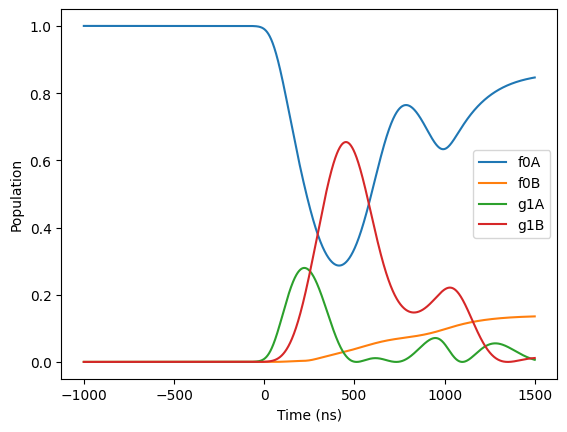

10.0%. Run time:   1.50s. Est. time left: 00:00:00:13
20.0%. Run time:   2.99s. Est. time left: 00:00:00:11
30.0%. Run time:   4.48s. Est. time left: 00:00:00:10
40.0%. Run time:   6.02s. Est. time left: 00:00:00:09
50.0%. Run time:   8.06s. Est. time left: 00:00:00:08
60.0%. Run time:   9.77s. Est. time left: 00:00:00:06
70.0%. Run time:  12.14s. Est. time left: 00:00:00:05
80.0%. Run time: 109.67s. Est. time left: 00:00:00:27
90.0%. Run time: 122.61s. Est. time left: 00:00:00:13
100.0%. Run time: 124.24s. Est. time left: 00:00:00:00
Total run time: 124.24s


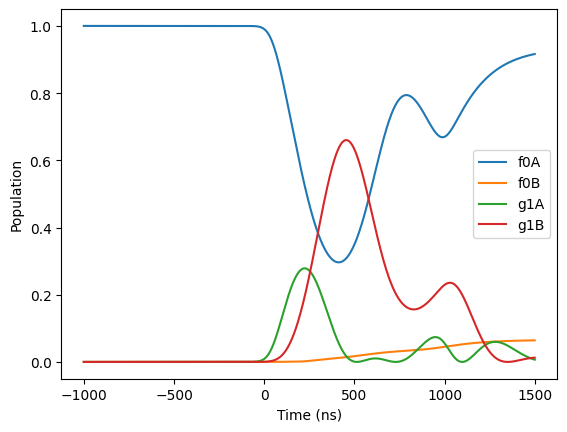

10.0%. Run time:   1.48s. Est. time left: 00:00:00:13
20.0%. Run time:   2.98s. Est. time left: 00:00:00:11
30.0%. Run time:   4.47s. Est. time left: 00:00:00:10
40.0%. Run time:   6.04s. Est. time left: 00:00:00:09
50.0%. Run time:   8.09s. Est. time left: 00:00:00:08
60.0%. Run time:   9.78s. Est. time left: 00:00:00:06
70.0%. Run time:  12.38s. Est. time left: 00:00:00:05
80.0%. Run time: 107.65s. Est. time left: 00:00:00:26
90.0%. Run time: 121.10s. Est. time left: 00:00:00:13
100.0%. Run time: 122.73s. Est. time left: 00:00:00:00
Total run time: 122.73s


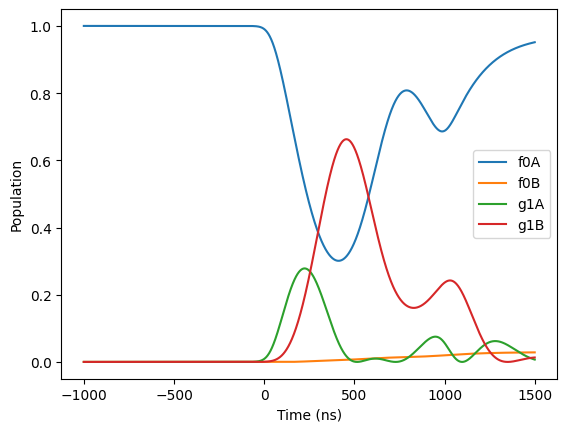

10.0%. Run time:   1.45s. Est. time left: 00:00:00:13
20.0%. Run time:   2.98s. Est. time left: 00:00:00:11
30.0%. Run time:   4.48s. Est. time left: 00:00:00:10
40.0%. Run time:   6.08s. Est. time left: 00:00:00:09
50.0%. Run time:   8.15s. Est. time left: 00:00:00:08
60.0%. Run time:   9.83s. Est. time left: 00:00:00:06
70.0%. Run time:  12.47s. Est. time left: 00:00:00:05
80.0%. Run time: 105.36s. Est. time left: 00:00:00:26
90.0%. Run time: 118.13s. Est. time left: 00:00:00:13
100.0%. Run time: 119.80s. Est. time left: 00:00:00:00
Total run time: 119.80s


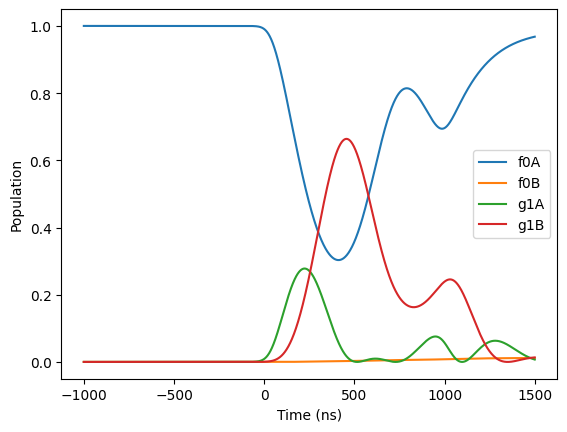

10.0%. Run time:   1.50s. Est. time left: 00:00:00:13
20.0%. Run time:   3.00s. Est. time left: 00:00:00:11
30.0%. Run time:   4.51s. Est. time left: 00:00:00:10
40.0%. Run time:   6.30s. Est. time left: 00:00:00:09
50.0%. Run time:   8.23s. Est. time left: 00:00:00:08
60.0%. Run time:   9.90s. Est. time left: 00:00:00:06
70.0%. Run time:  12.13s. Est. time left: 00:00:00:05
80.0%. Run time: 105.48s. Est. time left: 00:00:00:26
90.0%. Run time: 118.26s. Est. time left: 00:00:00:13
100.0%. Run time: 119.93s. Est. time left: 00:00:00:00
Total run time: 119.93s


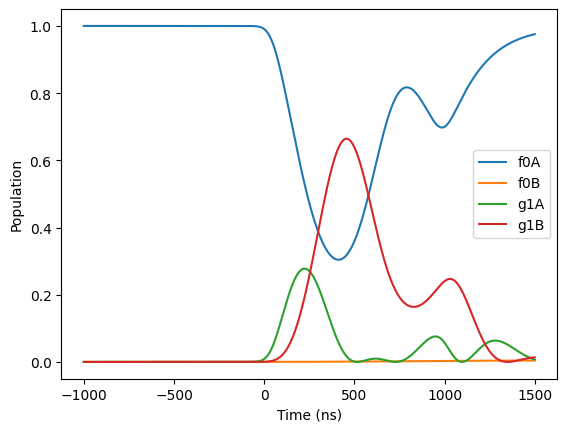

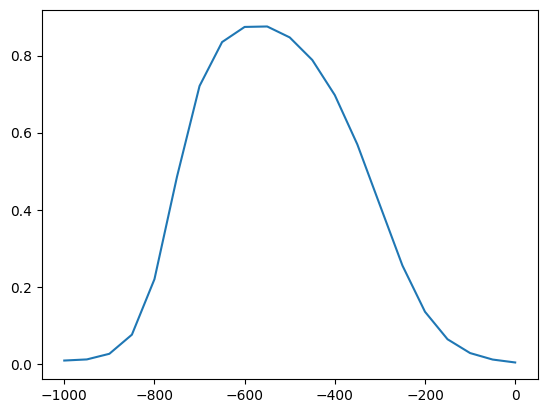

In [4]:
def H(t, args):
    return H_fogi_A(t, args)+H_fogi_B(t, args)+H_c(t, args)

# def c_ops(t, args):
#     return np.sqrt(args["kappa_A"]*args["eta"])*a_A +  np.sqrt(args["kappa_B"])*a_B

eta = 1
const = 2.5e-3 * 2 * np.pi
kappa_A = 0.001 * 2 * np.pi
kappa_B = 0.001 * 2 * np.pi
mode_A = "sech_0"
mode_B = "sech_1"
delay = np.linspace(-1000, 0, 21)

c_ops = []
e_ops = [f0_A.proj(), f0_B.proj(), g1_A.proj(), g1_B.proj()]
e_labels = ["f0A", "f0B", "g1A", "g1B"]
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=3000, max_step=0.5, store_states=False)
psi0 = f0_A
t = np.linspace(-1000, 1500, 2501)

f0B = []
def result(delay):   
    for tau in delay:
        result = qt.mesolve(
            H, psi0, t, c_ops, e_ops,
            args={"center_A":0, "center_B":tau, "eta":eta, "time0":t[0], "const":const, "kappa_A":kappa_A, "kappa_B":kappa_B, "mode_A":mode_A, "mode_B":mode_B},
            options=options, progress_bar=True
        )
        fig = plt.figure()
        ax = fig.add_subplot(1, 1, 1)
        for i, l in enumerate(e_labels):
            exp = np.abs(result.expect[i])
            ax.plot(t, exp, label=l)
            if i == 1:
                f0B.append(exp[-1])
        ax.legend()
        ax.set_xlabel("Time (ns)") ;ax.set_ylabel("Population")
        plt.show()
    return f0B

plt.plot(delay, result(delay))

In [ ]:
def H(t, args):
    return H_fogi_A(t, args)+H_fogi_B(t, args)+H_c(t, args)

c_ops = []#np.sqrt(kappa_A*eta)*a_A + np.sqrt(kappa_B)*a_B, np.sqrt(kappa_A*(1-eta))*a_A]
e_ops = [f0_A.proj(), f0_B.proj(), g1_A.proj(), g1_B.proj()]
e_labels = ["f0A", "f0B", "g1A", "g1B"]
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.5, store_states=False)
psi0 = f0_A
t = np.linspace(-1000, 1500, 1251)

eta = 1
kappa_A = 0.001 * 2 * np.pi
kappa_B = 0.001 * 2 * np.pi
mode_A = "sech_1"
mode_B = "sech_1"

result = qt.mesolve(
    H, psi0, t, c_ops, e_ops,
    args={"center_A":0, "center_B":-500, "eta":eta, "time0":t[0], "const":const, "kappa_A":kappa_A, "kappa_B":kappa_B, "mode_A":mode_A, "mode_B":mode_B},
    options=options, progress_bar=True
)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
for i, l in enumerate(e_labels):
    ax.plot(t, np.abs(result.expect[i]), label=l)
ax.legend()
ax.set_xlabel("Time (ns)") ;ax.set_ylabel("Population")
plt.show()
